In [1]:
import pandas as pd

In [2]:
rrp = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/real_risk_premieum.csv')

In [3]:
#import an xlsx file
df = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/DataExport_office_v2.xlsx')

In [4]:
df.head()

,Property Class Name,Period,Slice,As Of,Geography Name,Geography Code,Forecast Scenario,CBSA Code,Geography Type,Appreciation Return,...,Under Construction Buildings,Under Construction SF,Vacancy Rate,Vacant Available %,Vacant Available SF Direct,Vacant Available SF Sublet,Vacant Available SF Total,Vacant SF Direct,Vacant SF Sublet,Vacant SF Total
0,Office,2000 Q1,All,2025 Q1,Abilene - TX USA,G2-10180,Base Case,10180,Metro,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Office,2000 Q2,All,2025 Q1,Abilene - TX USA,G2-10180,Base Case,10180,Metro,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Office,2000 Q3,All,2025 Q1,Abilene - TX USA,G2-10180,Base Case,10180,Metro,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Office,2000 Q4,All,2025 Q1,Abilene - TX USA,G2-10180,Base Case,10180,Metro,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Office,2001 Q1,All,2025 Q1,Abilene - TX USA,G2-10180,Base Case,10180,Metro,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#create a subset where column Population is greater than 500000
df = df[df['Population'] > 500000]

In [6]:
df = df[~df['Period'].str.startswith('2025')]


In [7]:
df = df[df['Geography Name'].str.contains('Atlanta')]

In [8]:
df.head()

,Property Class Name,Period,Slice,As Of,Geography Name,Geography Code,Forecast Scenario,CBSA Code,Geography Type,Appreciation Return,...,Under Construction Buildings,Under Construction SF,Vacancy Rate,Vacant Available %,Vacant Available SF Direct,Vacant Available SF Sublet,Vacant Available SF Total,Vacant SF Direct,Vacant SF Sublet,Vacant SF Total
1632,Office,2000 Q1,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,0.019962,...,341.0,12146371.0,0.080448,0.078483,17009335.0,2931319.0,19940654.0,17473979.0,2965740.0,20439719.0
1633,Office,2000 Q2,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,0.000296,...,338.0,13082838.0,0.068836,0.067366,15134847.0,2126062.0,17260909.0,15511601.0,2126062.0,17637663.0
1634,Office,2000 Q3,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,-0.009518,...,338.0,15203495.0,0.084894,0.071996,16103943.0,2497091.0,18601034.0,19090861.0,2842254.0,21933115.0
1635,Office,2000 Q4,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,-0.024473,...,318.0,14520495.0,0.086197,0.076528,17236519.0,2778848.0,20015367.0,19539110.0,3005130.0,22544240.0
1636,Office,2001 Q1,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,-0.030379,...,249.0,12942950.0,0.093386,0.081496,18459195.0,3073877.0,21533072.0,21445546.0,3229085.0,24674631.0


In [9]:
#convert to time series
def convert_period_to_datetime(period):
	year, quarter = period.split('Q')
	month = (int(quarter) - 1) * 3 + 1
	return pd.Timestamp(year=int(year), month=month, day=1)

df['Period'] = df['Period'].apply(convert_period_to_datetime)

In [10]:
df.head()

,Property Class Name,Period,Slice,As Of,Geography Name,Geography Code,Forecast Scenario,CBSA Code,Geography Type,Appreciation Return,...,Under Construction Buildings,Under Construction SF,Vacancy Rate,Vacant Available %,Vacant Available SF Direct,Vacant Available SF Sublet,Vacant Available SF Total,Vacant SF Direct,Vacant SF Sublet,Vacant SF Total
1632,Office,2000-01-01,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,0.019962,...,341.0,12146371.0,0.080448,0.078483,17009335.0,2931319.0,19940654.0,17473979.0,2965740.0,20439719.0
1633,Office,2000-04-01,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,0.000296,...,338.0,13082838.0,0.068836,0.067366,15134847.0,2126062.0,17260909.0,15511601.0,2126062.0,17637663.0
1634,Office,2000-07-01,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,-0.009518,...,338.0,15203495.0,0.084894,0.071996,16103943.0,2497091.0,18601034.0,19090861.0,2842254.0,21933115.0
1635,Office,2000-10-01,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,-0.024473,...,318.0,14520495.0,0.086197,0.076528,17236519.0,2778848.0,20015367.0,19539110.0,3005130.0,22544240.0
1636,Office,2001-01-01,All,2025 Q1,Atlanta - GA USA,G2-12060,Base Case,12060,Metro,-0.030379,...,249.0,12942950.0,0.093386,0.081496,18459195.0,3073877.0,21533072.0,21445546.0,3229085.0,24674631.0


## select columns

In [11]:
#print column names
print(df.columns)

Index(['Property Class Name', 'Period', 'Slice', 'As Of', 'Geography Name',
       'Geography Code', 'Forecast Scenario', 'CBSA Code', 'Geography Type',
       'Appreciation Return', 'Asset Value', 'Availability Rate',
       'Availability Rate % Direct', 'Availability Rate % Sublet',
       'Available SF Direct', 'Available SF Sublet', 'Available SF Total',
       'Average Sale Price', 'Cap Rate', 'Cap Rate Transactions',
       'Capital Value Index', 'Construction Starts SF',
       'Construction Starts SF 12 Mo', 'Demand SF', 'Demolished SF',
       'Existing Buildings', 'Gross Delivered Buildings', 'Gross Delivered SF',
       'Households', 'Income Return', 'Industrial Employment', 'Inventory SF',
       'Leasing SF Direct', 'Leasing SF Sublet', 'Leasing SF Total',
       'Market Asking Rent Growth', 'Market Asking Rent Growth 12 Mo',
       'Market Asking Rent Index', 'Market Asking Rent/SF', 'Market Cap Rate',
       'Market Sale Price Growth', 'Market Sale Price Index',
       '

In [12]:
df['Total Sales Transactions'].head(500)

1632     66.0
1633    104.0
1634     79.0
1635     85.0
1636     78.0
        ...  
1727    185.0
1728    201.0
1729    179.0
1730    246.0
1731    239.0
Name: Total Sales Transactions, Length: 100, dtype: float64

In [13]:
import pandas as pd

# Let's assume your original DataFrame is named `df`.
# First, select only the columns you need:
df = df[
    [
        "Geography Name",
        "Period",
        "Appreciation Return",
        "Availability Rate",
        "Available SF Direct",
        "Average Sale Price",
        "Cap Rate",
        "Market Cap Rate",
        "Construction Starts SF",
        "Construction Starts SF 12 Mo",
        "Demand SF",
        "Demolished SF",
        "Gross Delivered SF",
        "Inventory SF",
        "Leasing SF Total",
        "Market Asking Rent Growth",
        "Market Asking Rent Growth 12 Mo",
        "Net Absorption SF",
        "Net Absorption SF 12 Mo",
        "Net Delivered SF",
        "Net Delivered SF 12 Mo",
        "Occupancy Rate",
        "Sales Volume Transactions",
        "Sold Building SF",
        "Vacancy Rate",
        "Under Construction SF",
        "Total Sales Transactions"
    ]
].copy()

# Next, rename columns
df.rename(
    columns={
        "Geography Name": "geography",
        "Period": "period",
        "Appreciation Return": "appreciation_return",
        "Availability Rate": "availability_rate",
        "Available SF Direct": "available_df_direct",
        "Average Sale Price": "avg_sale_price",
        "Cap Rate": "cap_rate",
        "Market Cap Rate": "market_cap_rate",
        "Construction Starts SF": "starts_sf",
        "Construction Starts SF 12 Mo": "starts_sf_12_mo",
        "Demand SF": "demand_sf",
        "Demolished SF": "demolished_sf",
        "Gross Delivered SF": "gross_delivered_sf",
        "Inventory SF": "inventory_sf",
        "Leasing SF Total": "leasing_sf_total",
        "Market Asking Rent Growth": "asking_rent_growth",
        "Market Asking Rent Growth 12 Mo": "asking_rent_growth_12_mo",
        "Net Absorption SF": "net_absorp_sf",
        "Net Absorption SF 12 Mo": "net_absorp_sf_12_mo",
        "Net Delivered SF": "net_delivered_sf",
        "Net Delivered SF 12 Mo": "net_delivered_sf_12_mo",
        "Occupancy Rate": "occupancy_rate",
        "Sales Volume Transactions": "sales_volume",
        "Sold Building SF": "sold_building_sf",
        "Vacancy Rate": "vacancy_rate",
        "Under Construction SF": "under_construction_sf",
        "Total Sales Transactions": "total_sales_transactions"
    },
    inplace=True
)

# Now `df_subset` has only the specified columns, each renamed as indicated.


In [14]:
df.head()

,geography,period,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,...,net_absorp_sf,net_absorp_sf_12_mo,net_delivered_sf,net_delivered_sf_12_mo,occupancy_rate,sales_volume,sold_building_sf,vacancy_rate,under_construction_sf,total_sales_transactions
1632,Atlanta - GA USA,2000-01-01,0.019962,NaN,NaN,5662759.0,0.098645,0.097076,3513818.0,13834133.0,...,4044684.0,11239781.0,3723806.0,13084822,0.919552,66.0,3097579.0,0.080448,12146371.0,66.0
1633,Atlanta - GA USA,2000-04-01,0.000296,NaN,NaN,4170181.0,0.102436,0.097372,3087883.0,12950512.0,...,4953472.0,12145800.0,2151416.0,11705650,0.931164,95.0,3248929.0,0.068836,13082838.0,104.0
1634,Atlanta - GA USA,2000-07-01,-0.009518,NaN,NaN,3275183.0,0.104880,0.099131,4253537.0,13824219.0,...,-2164316.0,6454890.0,2132880.0,11248306,0.915106,78.0,2261912.0,0.084894,15203495.0,79.0
1635,Atlanta - GA USA,2000-10-01,-0.024473,NaN,NaN,4558434.0,0.103688,0.099501,2549278.0,13404516.0,...,2573153.0,9406993.0,3184278.0,11192380,0.913803,81.0,3686215.0,0.086197,14520495.0,85.0
1636,Atlanta - GA USA,2001-01-01,-0.030379,NaN,NaN,1512973.0,0.109862,0.100116,1146188.0,11036886.0,...,547928.0,5910237.0,2678319.0,10146893,0.906614,78.0,1506863.0,0.093386,12942950.0,78.0


In [15]:
ff = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/FEDFUNDS (1).xlsx')

In [16]:
ff.head()

,period,fed_funds_rate
0,2000-01-01,5.45
1,2000-02-01,5.73
2,2000-03-01,5.85
3,2000-04-01,6.02
4,2000-05-01,6.27


In [17]:
#merge ff with df_subset using the period column
df = pd.merge(df, ff, on='period', how='left')
df.head()

,geography,period,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,...,net_absorp_sf_12_mo,net_delivered_sf,net_delivered_sf_12_mo,occupancy_rate,sales_volume,sold_building_sf,vacancy_rate,under_construction_sf,total_sales_transactions,fed_funds_rate
0,Atlanta - GA USA,2000-01-01,0.019962,NaN,NaN,5662759.0,0.098645,0.097076,3513818.0,13834133.0,...,11239781.0,3723806.0,13084822,0.919552,66.0,3097579.0,0.080448,12146371.0,66.0,5.45
1,Atlanta - GA USA,2000-04-01,0.000296,NaN,NaN,4170181.0,0.102436,0.097372,3087883.0,12950512.0,...,12145800.0,2151416.0,11705650,0.931164,95.0,3248929.0,0.068836,13082838.0,104.0,6.02
2,Atlanta - GA USA,2000-07-01,-0.009518,NaN,NaN,3275183.0,0.104880,0.099131,4253537.0,13824219.0,...,6454890.0,2132880.0,11248306,0.915106,78.0,2261912.0,0.084894,15203495.0,79.0,6.54
3,Atlanta - GA USA,2000-10-01,-0.024473,NaN,NaN,4558434.0,0.103688,0.099501,2549278.0,13404516.0,...,9406993.0,3184278.0,11192380,0.913803,81.0,3686215.0,0.086197,14520495.0,85.0,6.51
4,Atlanta - GA USA,2001-01-01,-0.030379,NaN,NaN,1512973.0,0.109862,0.100116,1146188.0,11036886.0,...,5910237.0,2678319.0,10146893,0.906614,78.0,1506863.0,0.093386,12942950.0,78.0,5.98


In [18]:
bond = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/bond_yield_10yr.xlsx')

In [19]:
bond.head()

,period,bond_yield_10yr
0,2000-01-01,6.480000
1,2000-04-01,6.176667
2,2000-07-01,5.893333
3,2000-10-01,5.566667
4,2001-01-01,5.050000


In [20]:
#merge bond with df_subset using the period column
df = pd.merge(df, bond, on='period', how='left')

In [21]:
#multiply by 100 availability rate
df['availability'] = df['availability_rate'] * 100
df['cap_rate'] = df['cap_rate'] * 100
df['market_cap_rate'] = df['market_cap_rate'] * 100
df['asking_rent_growth'] = df['asking_rent_growth'] * 100
df['asking_rent_growth_12_mo'] = df['asking_rent_growth_12_mo'] * 100
df['occupancy_rate'] = df['occupancy_rate'] * 100
df['vacancy_rate'] = df['vacancy_rate'] * 100
df['appreciation_return'] = df['appreciation_return'] * 100

In [22]:
df.head()

,geography,period,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,...,net_delivered_sf_12_mo,occupancy_rate,sales_volume,sold_building_sf,vacancy_rate,under_construction_sf,total_sales_transactions,fed_funds_rate,bond_yield_10yr,availability
0,Atlanta - GA USA,2000-01-01,1.996212,NaN,NaN,5662759.0,9.864546,9.707598,3513818.0,13834133.0,...,13084822,91.955221,66.0,3097579.0,8.044778,12146371.0,66.0,5.45,6.480000,NaN
1,Atlanta - GA USA,2000-04-01,0.029603,NaN,NaN,4170181.0,10.243572,9.737211,3087883.0,12950512.0,...,11705650,93.116361,95.0,3248929.0,6.883641,13082838.0,104.0,6.02,6.176667,NaN
2,Atlanta - GA USA,2000-07-01,-0.951823,NaN,NaN,3275183.0,10.488000,9.913068,4253537.0,13824219.0,...,11248306,91.510594,78.0,2261912.0,8.489406,15203495.0,79.0,6.54,5.893333,NaN
3,Atlanta - GA USA,2000-10-01,-2.447272,NaN,NaN,4558434.0,10.368750,9.950081,2549278.0,13404516.0,...,11192380,91.380292,81.0,3686215.0,8.619709,14520495.0,85.0,6.51,5.566667,NaN
4,Atlanta - GA USA,2001-01-01,-3.037886,NaN,NaN,1512973.0,10.986154,10.011605,1146188.0,11036886.0,...,10146893,90.661377,78.0,1506863.0,9.338625,12942950.0,78.0,5.98,5.050000,NaN


In [23]:
#ignore the columns geography and period, and then run a correlation matrix. print the top correlations in ascending order for market_cap_rate

df_corr = df.drop(columns=['period', 'geography']).corr()
print(df_corr['market_cap_rate'].sort_values(ascending=True).head(10))
print(df_corr['market_cap_rate'].sort_values(ascending=False).head(10))

# Print the entire correlation matrix
print(df_corr)

sales_volume               -0.764603
total_sales_transactions   -0.738033
demand_sf                  -0.695771
asking_rent_growth         -0.669823
asking_rent_growth_12_mo   -0.652972
sold_building_sf           -0.652660
inventory_sf               -0.615967
avg_sale_price             -0.451536
appreciation_return        -0.367267
demolished_sf              -0.194893
Name: market_cap_rate, dtype: float64
market_cap_rate           1.000000
availability              0.631926
availability_rate         0.631926
cap_rate                  0.627733
bond_yield_10yr           0.603706
net_delivered_sf_12_mo    0.577406
available_df_direct       0.547109
leasing_sf_total          0.455439
net_delivered_sf          0.451587
gross_delivered_sf        0.429589
Name: market_cap_rate, dtype: float64
                          appreciation_return  availability_rate  \
appreciation_return                  1.000000          -0.234445   
availability_rate                   -0.234445           1.000000   


In [24]:
df_corr.head()

,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,demand_sf,demolished_sf,...,net_delivered_sf_12_mo,occupancy_rate,sales_volume,sold_building_sf,vacancy_rate,under_construction_sf,total_sales_transactions,fed_funds_rate,bond_yield_10yr,availability
appreciation_return,1.000000,-0.234445,-0.163258,0.305314,0.152418,-0.367267,0.216431,0.135009,-0.173032,-0.216626,...,0.010865,0.067804,0.241337,0.318914,-0.067804,0.049679,0.159302,-0.204101,-0.140004,-0.234445
availability_rate,-0.234445,1.000000,0.977463,-0.598480,0.166649,0.631926,-0.605108,-0.750499,-0.043450,-0.030466,...,-0.395195,-0.942991,-0.314387,-0.549166,0.942991,-0.779672,-0.243535,-0.186626,-0.049384,1.000000
available_df_direct,-0.163258,0.977463,1.000000,-0.604951,0.157012,0.547109,-0.638282,-0.791703,0.116511,-0.030510,...,-0.459117,-0.887089,-0.178508,-0.509692,0.887089,-0.771116,-0.077948,-0.256576,-0.202692,0.977463
avg_sale_price,0.305314,-0.598480,-0.604951,1.000000,-0.224545,-0.451536,0.403144,0.337404,0.024728,-0.015975,...,0.111422,0.322742,0.309868,0.838339,-0.322742,0.319861,0.219918,0.234722,0.133160,-0.598480
cap_rate,0.152418,0.166649,0.157012,-0.224545,1.000000,0.627733,0.252157,0.354129,-0.704185,-0.140588,...,0.482499,0.219731,-0.506005,-0.345547,-0.219731,0.278124,-0.526906,0.002109,0.349054,0.166649


10 Most Negative Correlations with market_cap_rate:
sales_volume               -0.764603
total_sales_transactions   -0.738033
demand_sf                  -0.695771
asking_rent_growth         -0.669823
asking_rent_growth_12_mo   -0.652972
sold_building_sf           -0.652660
inventory_sf               -0.615967
avg_sale_price             -0.451536
appreciation_return        -0.367267
demolished_sf              -0.194893
Name: market_cap_rate, dtype: float64

10 Most Positive Correlations with market_cap_rate:
market_cap_rate           1.000000
availability              0.631926
availability_rate         0.631926
cap_rate                  0.627733
bond_yield_10yr           0.603706
net_delivered_sf_12_mo    0.577406
available_df_direct       0.547109
leasing_sf_total          0.455439
net_delivered_sf          0.451587
gross_delivered_sf        0.429589
Name: market_cap_rate, dtype: float64


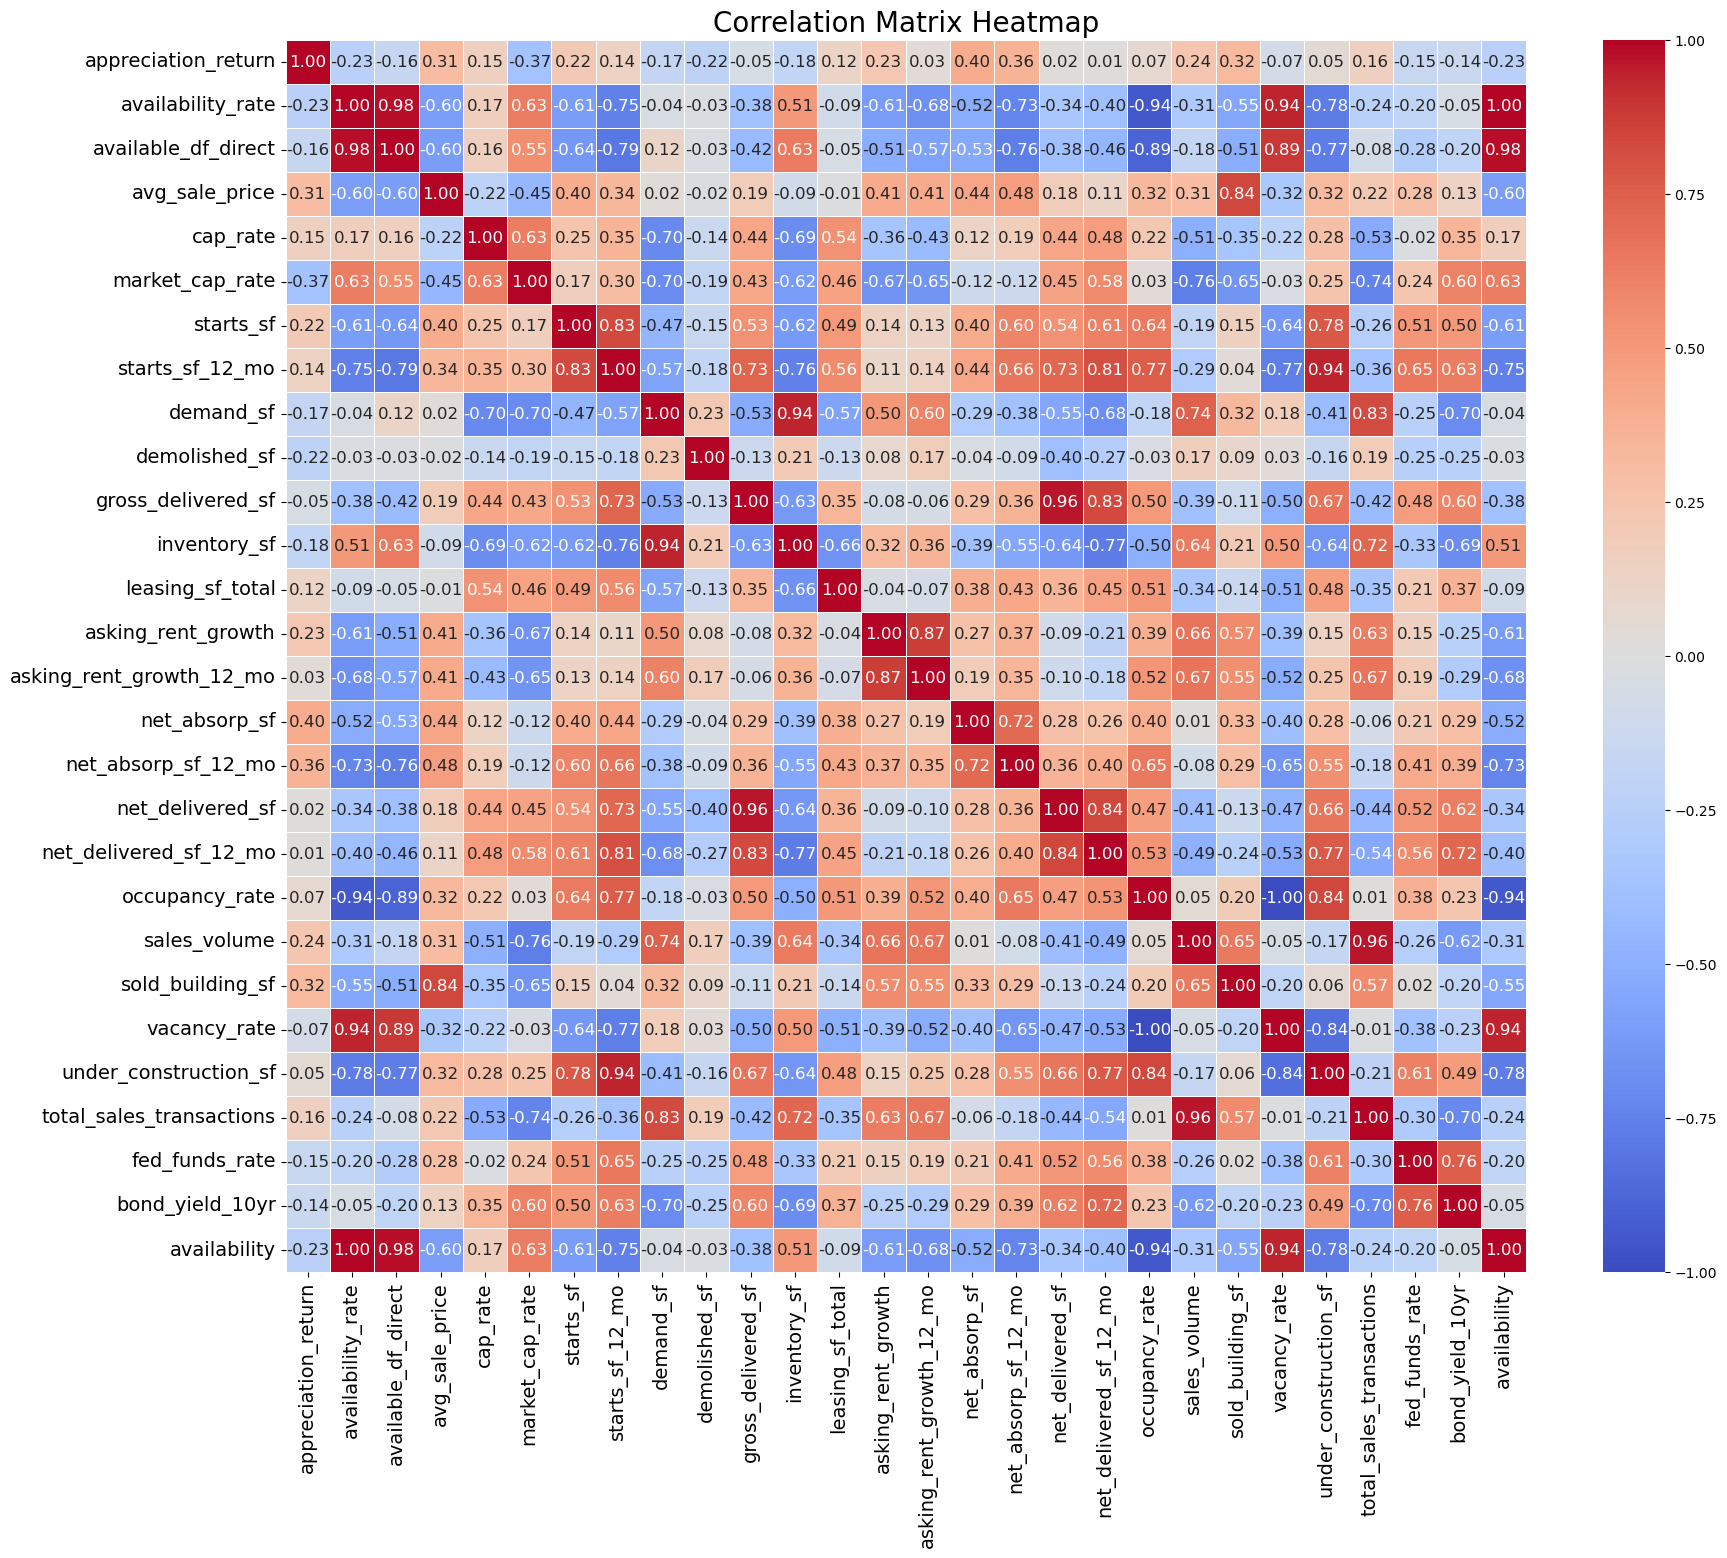

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop columns 'period' and 'geography' (if they exist)
df_subset = df.drop(columns=['period', 'geography'], errors='ignore')

# 2. Compute the correlation matrix
df_corr = df_subset.corr()

# 3. Print the 10 most negative correlations with 'market_cap_rate'
if 'market_cap_rate' in df_corr.columns:
    print("10 Most Negative Correlations with market_cap_rate:")
    print(df_corr['market_cap_rate'].sort_values(ascending=True).head(10))

    # 4. Print the 10 most positive correlations with 'market_cap_rate'
    print("\n10 Most Positive Correlations with market_cap_rate:")
    print(df_corr['market_cap_rate'].sort_values(ascending=False).head(10))
else:
    print("Column 'market_cap_rate' not found in correlation matrix.")

# 5. Plot the correlation matrix as a heatmap
#plt.figure(figsize=(20, 16))  # Increase the figure size
#sns.heatmap(df_corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5, annot_kws={"size": 12})  # Increase the annotation size
#plt.title('Correlation Matrix Heatmap')
#plt.show()

# 5. Plot the correlation matrix as a heatmap
plt.figure(figsize=(20, 16))  # Increase the figure size
heatmap = sns.heatmap(df_corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5, annot_kws={"size": 12})  # Increase the annotation size
plt.title('Correlation Matrix Heatmap', fontsize=20)  # Increase the title size

# Increase the size of the variable names (axis labels)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()


In [41]:
#print all the correlation for market_cap_rate
print(df_corr['asking_rent_growth'].sort_values(ascending=False))

asking_rent_growth           1.000000
asking_rent_growth_12_mo     0.872828
Sales Volume Transactions    0.664729
total_sales_transactions     0.630037
sold_building_sf             0.565507
demand_sf                    0.504917
avg_sale_price               0.413437
occupancy_rate               0.390400
net_absorp_sf_12_mo          0.369420
inventory_sf                 0.318124
net_absorp_sf                0.266123
appreciation_return          0.226566
fed_funds_rate               0.152623
under_construction_sf        0.145516
starts_sf                    0.140496
starts_sf_12_mo              0.105127
demolished_sf                0.080241
leasing_sf_total            -0.043633
gross_delivered_sf          -0.075419
net_delivered_sf            -0.092043
net_delivered_sf_12_mo      -0.211022
bond_yield_10yr             -0.246600
cap_rate                    -0.357651
vacancy_rate                -0.390400
available_df_direct         -0.511367
availability_rate           -0.612067
availability

# check stationarity, conduct cross correlation checks, determine optimal lags for predicting market_cap_rate

In [46]:
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.stattools import ccf
import numpy as np

In [43]:
def test_stationarity(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f"ADF p-value for {name}: {p_value:.4f}")
    if p_value > 0.05:
        print(f"Warning: {name} is non-stationary. Apply differencing.")
    else:
        print(f"{name} is stationary.")
    return p_value

In [58]:
# Test stationarity
p_market = test_stationarity(df['market_cap_rate'], 'market_cap_rate')
p_bond = test_stationarity(df['bond_yield_10yr'], 'bond_yield_10yr')

ADF p-value for market_cap_rate: 0.0387
market_cap_rate is stationary.
ADF p-value for bond_yield_10yr: 0.1531


In [59]:
# Difference non-stationary series
if p_market > 0.05:
    df['market_cap_rate_diff'] = df['market_cap_rate'].diff().dropna()
if p_bond > 0.05:
    df['bond_yield_10yr_diff'] = df['bond_yield_10yr'].diff().dropna()

# Drop NaN rows created by differencing
df = df.dropna()

# Check stationarity again (if differenced)
if 'market_cap_rate_diff' in df.columns:
    test_stationarity(df['market_cap_rate_diff'], 'Differenced market_cap_rate')
if 'bond_yield_10yr_diff' in df.columns:
    test_stationarity(df['bond_yield_10yr_diff'], 'Differenced bond_yield_10yr')

ADF p-value for Differenced bond_yield_10yr: 0.0000
Differenced bond_yield_10yr is stationary.


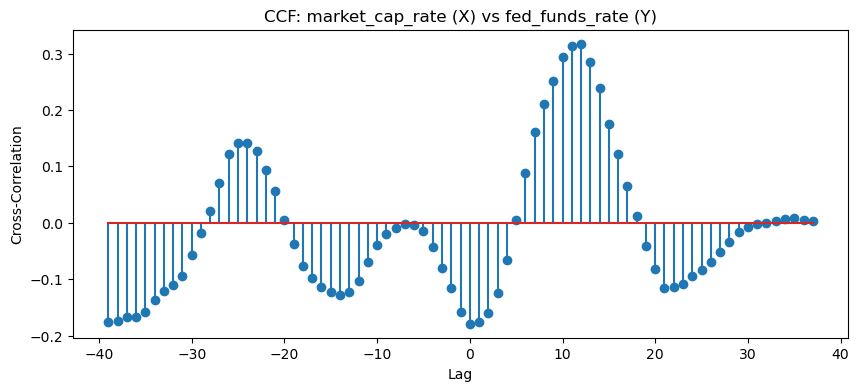

In [65]:
# Define X and Y (stationary versions)
X = df['market_cap_rate_diff'] if 'market_cap_rate_diff' in df.columns else df['market_cap_rate']
Y = df['bond_yield_10yr_diff'] if 'bond_yield_10yr_diff' in df.columns else df['bond_yield_10yr']

# Compute cross-correlation
ccf_values = ccf(Y, X, adjusted=False)  # Y vs X lags
lags = np.arange(-len(ccf_values)//2, len(ccf_values)//2)

# Plot CCF
plt.figure(figsize=(10, 4))
plt.stem(lags, ccf_values)
plt.xlabel('Lag')
plt.ylabel('Cross-Correlation')
plt.title('CCF: market_cap_rate (X) vs fed_funds_rate (Y)')
plt.show()

In [62]:
# Create a DataFrame with stationary series
data_granger = pd.DataFrame({'Y': Y, 'X': X})

# Set maxlag (e.g., 4 quarters for annual cycles)
maxlag = 10

# Test X Granger-causes Y
granger_XY = grangercausalitytests(data_granger[['Y', 'X']], maxlag=maxlag, verbose=False)
# Test Y Granger-causes X
granger_YX = grangercausalitytests(data_granger[['X', 'Y']], maxlag=maxlag, verbose=False)

# Extract p-values for lag=1 (or your chosen lag)
p_xy = [granger_XY[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]
p_yx = [granger_YX[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]

print(f"P-values for X Granger-causes Y (lags 1-{maxlag}): {p_xy}")
print(f"P-values for Y Granger-causes X (lags 1-{maxlag}): {p_yx}")

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


P-values for X Granger-causes Y (lags 1-10): [0.20483912790171546, 0.379452647903907, 0.44387863979769393, 0.6447781423083372, 0.7576050036143855, 0.8101192542260947, 0.8753987967215022, 0.8908550509982999, 0.7049952451881496, 0.7872108020003747]
P-values for Y Granger-causes X (lags 1-10): [0.8713502353131547, 0.9338361755457076, 0.7721061965234777, 0.877304098480455, 0.9000333888500183, 0.6838242894359119, 0.6419535875760491, 0.6697812635040378, 0.48933921281616644, 0.518348646793716]


In [68]:
from statsmodels.tsa.stattools import grangercausalitytests

# Test if X (market_cap_rate) Granger-causes Y (fed_funds_rate)
granger_xy = grangercausalitytests(df[['fed_funds_rate', 'market_cap_rate']], maxlag=12, verbose=False)

# Extract p-values for lag 12
p_value_lag12 = granger_xy[12][0]['ssr_ftest'][1]
print(f"Granger causality p-value at lag 12: {p_value_lag12:.4f}")

Granger causality p-value at lag 12: 0.0937


/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [70]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


### Testing Feature Importance with RandomForestRegressor

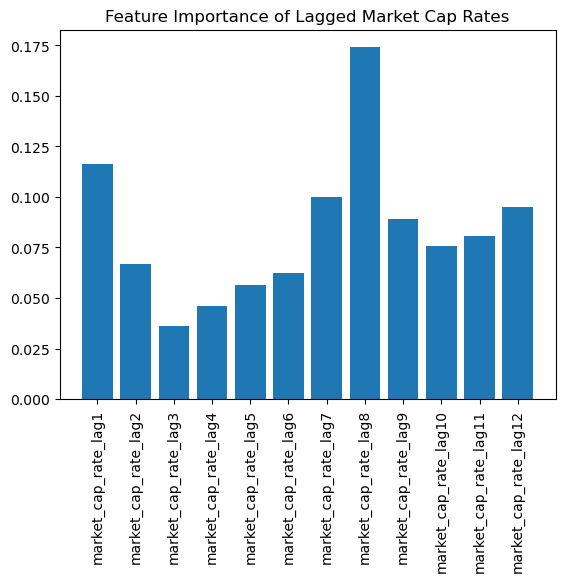

In [71]:
from sklearn.ensemble import RandomForestRegressor

# Create lagged features for X
for lag in range(1, 13):
    df[f'market_cap_rate_lag{lag}'] = df['market_cap_rate'].shift(lag)
df = df.dropna()

# Train model
model = RandomForestRegressor()
X = df.filter(like='market_cap_rate_lag')
y = df['fed_funds_rate']
model.fit(X, y)

# Plot feature importances
plt.bar(X.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance of Lagged Market Cap Rates")
plt.show()

In [73]:
confidence = 1.96 / np.sqrt(len(df))
print(f"95% confidence interval: ±{confidence:.3f}")

95% confidence interval: ±0.243


In [74]:
# Test if X (market_cap_rate) Granger-causes Y (fed_funds_rate)
granger_results = grangercausalitytests(df[['fed_funds_rate', 'market_cap_rate']], maxlag=8, verbose=False)

# Extract p-value for lag 8
p_value = granger_results[8][0]['ssr_ftest'][1]
print(f"Granger causality p-value at lag 8: {p_value:.4f}")

Granger causality p-value at lag 8: 0.3695


/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [171]:
df_test['asking_rent_growth'].head(10)

0    1.129821
1    1.253542
2    0.446790
3    0.601663
4   -0.100779
5   -0.051778
6   -1.217124
7   -1.045431
8   -1.389122
9   -0.837561
Name: asking_rent_growth, dtype: float64

### Apply the VAR Model  

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

Final dataset shape: (98, 2)
Variables: ['d1_market_cap_rate', 'd1_asking_rent_growth']

VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 16, Feb, 2025
Time:                     15:07:45
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -6.55162
Nobs:                     96.0000    HQIC:                  -6.71076
Log likelihood:           64.8631    FPE:                 0.00109331
AIC:                     -6.81874    Det(Omega_mle):     0.000987739
--------------------------------------------------------------------
Results for equation d1_market_cap_rate
                              coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------
const                            0.214217         0.061990            3.456    

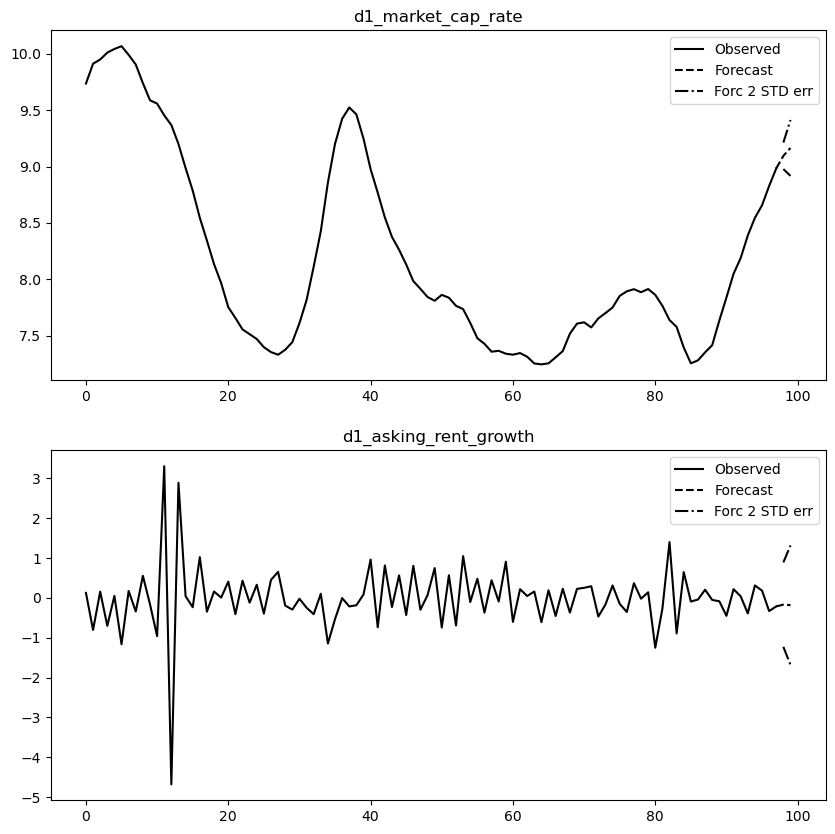

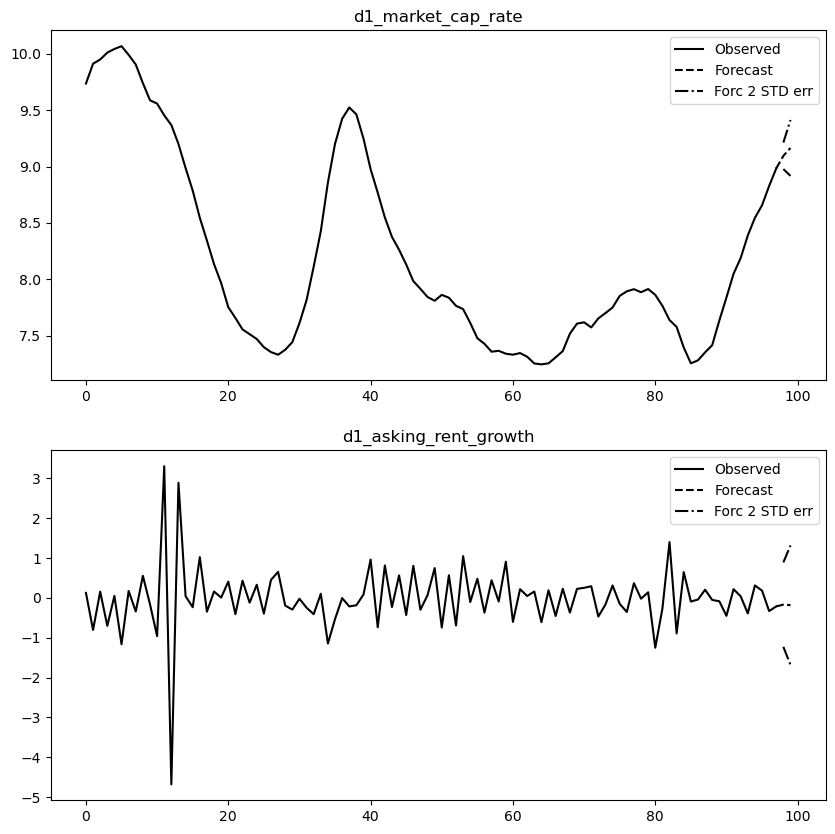

In [170]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson

# -------------------------------------------------
# 0. Variable Selection (ADD THIS SECTION)
# -------------------------------------------------
# List of key variables to include (customize based on domain knowledge)
selected_vars = [
    'market_cap_rate',  # Target variable
    'fed_funds_rate',
    'vacancy_rate',
    'bond_yield_10yr',
    'net_delivered_sf_12_mo',
    'starts_sf_12_mo',
    'under_construction_sf',
    'inventory_sf',
    'asking_rent_growth',
    'total_sales_transactions',
    'sales_volume'

]

# -------------------------------------------------
# 1. Data Preparation
# -------------------------------------------------
# Assuming df has 'period' column and selected variables
#df = df.set_index('period')  # Set time index
original_target = 'market_cap_rate'

# Filter dataframe to selected variables
df = df[selected_vars]

# -------------------------------------------------
# 2. Automated Preprocessing Pipeline (MODIFIED)
# -------------------------------------------------
def prepare_data(df, target_col, seasonal_period=8, selected_vars=None):
    """End-to-end preprocessing with target preservation"""
    
    # Filter to selected variables if provided
    if selected_vars:
        df = df[selected_vars]
    
    # Keep track of target through transformations
    target_transformations = []
    
    # A. Variance Stabilization
    cv_threshold = 0.5
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    for col in numeric_cols:
        series = df[col].dropna()
        if series.min() > 0:
            cv = series.std()/series.mean()
            if cv > cv_threshold:
                df[f'log_{col}'] = np.log(series)
                if col == target_col:
                    target_transformations.append(f'log_{col}')
            else:
                df[f'orig_{col}'] = series
                if col == target_col:
                    target_transformations.append(f'orig_{col}')
        else:
            df[f'orig_{col}'] = series
            if col == target_col:
                target_transformations.append(f'orig_{col}')
    
    # B. First Differencing
    transformed_cols = [c for c in df.columns if c.startswith(('log_', 'orig_'))]
    
    for col in transformed_cols:
        base_name = col.split('_', 1)[1]
        if adfuller(df[col].dropna())[1] > 0.05:
            df[f'd1_{base_name}'] = df[col].diff().dropna()
            if base_name == target_col:
                target_transformations.append(f'd1_{base_name}')
        else:
            df[f'd1_{base_name}'] = df[col]
    
    # C. Seasonal Differencing
    seasonal_cols = [c for c in df.columns if c.startswith('d1_')]
    
    for col in seasonal_cols:
        try:
            if adfuller(df[col].dropna())[1] > 0.05:
                df[f'sd{seasonal_period}_{col}'] = df[col].diff(seasonal_period).dropna()
        except:
            continue
    
    # D. Final Stationary Selection
    final_cols = []
    for col in df.columns:
        if col.startswith(('sd12_d1_', 'd1_')):
            if adfuller(df[col].dropna())[1] < 0.05:
                final_cols.append(col)
    
    # Ensure target is included
    final_target = target_transformations[-1]
    if final_target not in final_cols:
        final_cols.append(final_target)
    
    return df[final_cols].dropna()

# -------------------------------------------------
# 3. Execute Pipeline (MODIFIED)
# -------------------------------------------------
# Use either selected_vars or default to all variables
stationary_df = prepare_data(df, original_target, selected_vars=selected_vars)

# 4. Granger Causality Filtering
# -------------------------------------------------
def granger_filter(df, target_col, maxlag=2, p_threshold=0.05):
    """Select variables with Granger causal relationship"""
    candidate_vars = [col for col in df.columns if col != target_col]
    significant_vars = []
    
    for var in candidate_vars:
        try:
            test_result = grangercausalitytests(
                df[[target_col, var]], 
                maxlag=maxlag, 
                verbose=False
            )
            p_values = [test_result[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]
            if min(p_values) < p_threshold:
                significant_vars.append(var)
        except:
            continue
    
    return df[[target_col] + significant_vars]

filtered_df = granger_filter(stationary_df, 
                            target_col=stationary_df.filter(like='market_cap_rate').columns[0])

print(f"Final dataset shape: {filtered_df.shape}")
print(f"Variables: {filtered_df.columns.tolist()}")

# -------------------------------------------------
# 5. VAR Modeling
# -------------------------------------------------
def safe_var_model(df, maxlags=3):
    """VAR modeling with dimension checks"""
    T, k = df.shape
    max_feasible_lags = (T - 1) // (k + 1)  # Conservative estimate
    
    model = VAR(df)
    try:
        lag_results = model.select_order(maxlags=min(maxlags, max_feasible_lags))
        optimal_lag = lag_results.aic
    except:
        optimal_lag = 1
    
    return model.fit(optimal_lag)

var_model = safe_var_model(filtered_df)
print("\nVAR Model Summary:")
print(var_model.summary())

# -------------------------------------------------
# 6. Model Diagnostics
# -------------------------------------------------
print("\nResidual Autocorrelation Test:")
print("Durbin-Watson (want ~2):", durbin_watson(var_model.resid))

# Forecast visualization example
var_model.plot_forecast(steps=2)

In [158]:
df.head()

,geography,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,demand_sf,...,d1_occupancy_rate,d1_sales_volume,d1_sold_building_sf,d1_vacancy_rate,d1_under_construction_sf,d1_total_sales_transactions,d1_fed_funds_rate,d1_bond_yield_10yr,d1_availability,sd12_d1_under_construction_sf
period,,,,,,,,,,,,,,,,,,,,,
2000-01-01,Atlanta - GA USA,1.996212,NaN,NaN,5662759.0,9.864546,9.707598,3513818.0,13834133.0,233634640.0,...,NaN,NaN,14.946131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-01,Atlanta - GA USA,0.029603,NaN,NaN,4170181.0,10.243572,9.737211,3087883.0,12950512.0,238588112.0,...,1.161140,29.0,14.993836,-1.161136,0.074271,38.0,0.109965,-0.303333,NaN,NaN
2000-07-01,Atlanta - GA USA,-0.951823,NaN,NaN,3275183.0,10.488000,9.913068,4253537.0,13824219.0,236425552.0,...,-1.605767,-17.0,14.631721,1.605765,0.150224,-25.0,-0.001533,-0.283333,NaN,NaN
2000-10-01,Atlanta - GA USA,-2.447272,NaN,NaN,4558434.0,10.368750,9.950081,2549278.0,13404516.0,238998704.0,...,-0.130302,3.0,15.120111,0.130302,-0.045964,6.0,-0.018576,-0.326667,NaN,NaN
2001-01-01,Atlanta - GA USA,-3.037886,NaN,NaN,1512973.0,10.986154,10.011605,1146188.0,11036886.0,239546624.0,...,-0.718915,-3.0,14.225541,0.718916,-0.115010,-7.0,-0.186706,-0.516667,NaN,NaN


In [159]:
#check for nas
df.isna().sum()

geography                         0
appreciation_return               0
availability_rate                21
available_df_direct              21
avg_sale_price                    0
                                 ..
d1_total_sales_transactions       1
d1_fed_funds_rate                 2
d1_bond_yield_10yr                1
d1_availability                  21
sd12_d1_under_construction_sf    13
Length: 86, dtype: int64

### Let find out what affects rent growth

In [203]:
df = df.set_index('period')  # Set time index


In [204]:
df.head()

,geography,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,demand_sf,...,net_delivered_sf_12_mo,occupancy_rate,sales_volume,sold_building_sf,vacancy_rate,under_construction_sf,total_sales_transactions,fed_funds_rate,bond_yield_10yr,availability
period,,,,,,,,,,,,,,,,,,,,,
2000-01-01,Atlanta - GA USA,1.996212,NaN,NaN,5662759.0,9.864546,9.707598,3513818.0,13834133.0,233634640.0,...,13084822,91.955221,66.0,3097579.0,8.044778,12146371.0,66.0,5.85,6.480000,NaN
2000-04-01,Atlanta - GA USA,0.029603,NaN,NaN,4170181.0,10.243572,9.737211,3087883.0,12950512.0,238588112.0,...,11705650,93.116361,95.0,3248929.0,6.883641,13082838.0,104.0,6.53,6.176667,NaN
2000-07-01,Atlanta - GA USA,-0.951823,NaN,NaN,3275183.0,10.488000,9.913068,4253537.0,13824219.0,236425552.0,...,11248306,91.510594,78.0,2261912.0,8.489406,15203495.0,79.0,6.52,5.893333,NaN
2000-10-01,Atlanta - GA USA,-2.447272,NaN,NaN,4558434.0,10.368750,9.950081,2549278.0,13404516.0,238998704.0,...,11192380,91.380292,81.0,3686215.0,8.619709,14520495.0,85.0,6.40,5.566667,NaN
2001-01-01,Atlanta - GA USA,-3.037886,NaN,NaN,1512973.0,10.986154,10.011605,1146188.0,11036886.0,239546624.0,...,10146893,90.661377,78.0,1506863.0,9.338625,12942950.0,78.0,5.31,5.050000,NaN


In [201]:
#print columns
print(df.columns)

Index(['geography', 'period', 'appreciation_return', 'availability_rate',
       'available_df_direct', 'avg_sale_price', 'cap_rate', 'market_cap_rate',
       'starts_sf', 'starts_sf_12_mo', 'demand_sf', 'demolished_sf',
       'gross_delivered_sf', 'inventory_sf', 'leasing_sf_total',
       'asking_rent_growth', 'asking_rent_growth_12_mo', 'net_absorp_sf',
       'net_absorp_sf_12_mo', 'net_delivered_sf', 'net_delivered_sf_12_mo',
       'occupancy_rate', 'sales_volume', 'sold_building_sf', 'vacancy_rate',
       'under_construction_sf', 'total_sales_transactions', 'fed_funds_rate',
       'bond_yield_10yr', 'availability'],
      dtype='object')


In [ ]:
Index(['geography', 'period', 'appreciation_return', 'availability_rate',
       'available_df_direct', 'avg_sale_price', 'cap_rate', 'market_cap_rate',
       'starts_sf', 'starts_sf_12_mo', 'demand_sf', 'demolished_sf',
       'gross_delivered_sf', 'inventory_sf', 'leasing_sf_total',
       'asking_rent_growth', 'asking_rent_growth_12_mo', 'net_absorp_sf',
       'net_absorp_sf_12_mo', 'net_delivered_sf', 'net_delivered_sf_12_mo',
       'occupancy_rate', 'sales_volume', 'sold_building_sf', 'vacancy_rate',
       'under_construction_sf', 'total_sales_transactions', 'fed_funds_rate',
       'bond_yield_10yr', 'availability'],
      dtype='object')

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

Final dataset shape: (75, 14)
Variables: ['d1_appreciation_return', 'd1_available_df_direct', 'd1_avg_sale_price', 'd1_market_cap_rate', 'd1_demand_sf', 'd1_demolished_sf', 'd1_inventory_sf', 'd1_asking_rent_growth_12_mo', 'd1_net_absorp_sf', 'd1_net_absorp_sf_12_mo', 'd1_net_delivered_sf', 'd1_net_delivered_sf_12_mo', 'd1_sold_building_sf', 'd1_fed_funds_rate']

VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 16, Feb, 2025
Time:                     16:24:38
--------------------------------------------------------------------
No. of Equations:         14.0000    BIC:                    199.638
Nobs:                     72.0000    HQIC:                   188.181
Log likelihood:          -7329.99    FPE:                3.53671e+79
AIC:                      180.603    Det(Omega_mle):     5.02904e+76
--------------------------------------------------------------------
Results for equation d1_ap

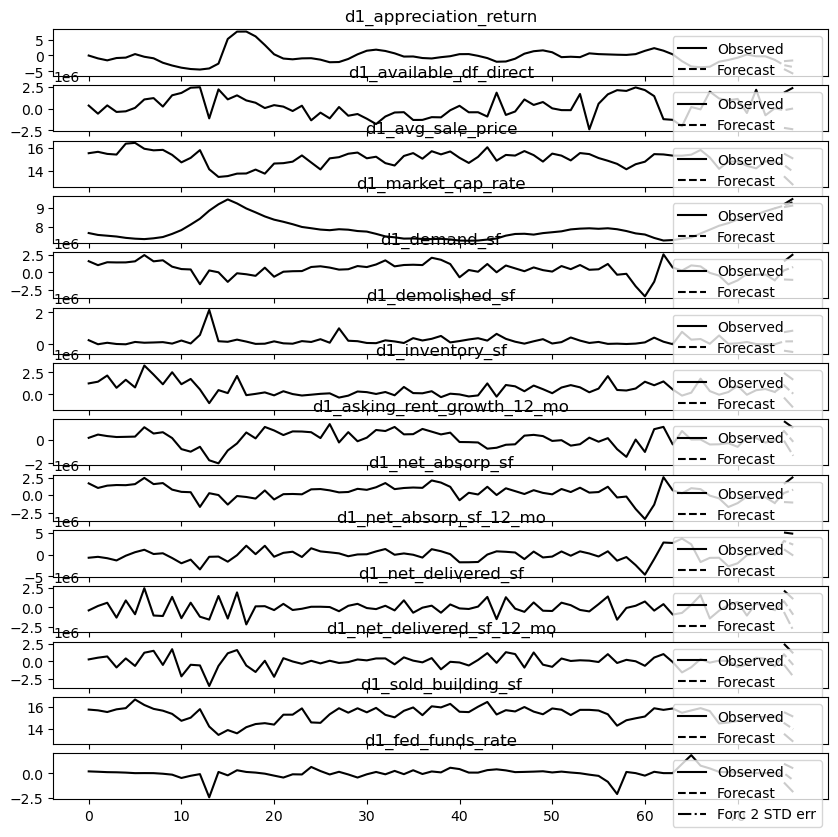

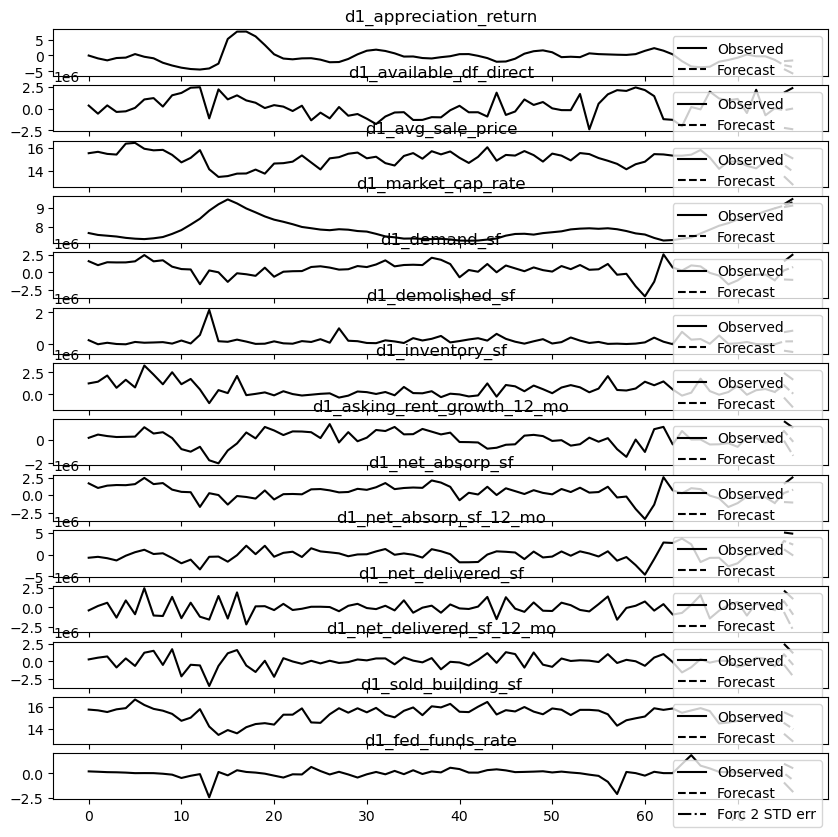

In [206]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson

# -------------------------------------------------
# 0. Variable Selection (ADD THIS SECTION)
# -------------------------------------------------
# List of key variables to include (customize based on domain knowledge)
selected_vars = [
    'appreciation_return', 
    'availability_rate',
    'available_df_direct', 
    'avg_sale_price', 
    'cap_rate', 
    'market_cap_rate',
    'starts_sf', 
    'starts_sf_12_mo', 
    'demand_sf', 
    'demolished_sf',
    'gross_delivered_sf', 
    'inventory_sf', 
    'leasing_sf_total',
    'asking_rent_growth', 
    'asking_rent_growth_12_mo', 
    'net_absorp_sf',
    'net_absorp_sf_12_mo', 
    'net_delivered_sf', 
    'net_delivered_sf_12_mo',
    'occupancy_rate', 'sales_volume',
    'sold_building_sf', 
    'vacancy_rate',
    'under_construction_sf', 
    'total_sales_transactions', 
    'fed_funds_rate',
    'bond_yield_10yr', 
    'availability'

]

# -------------------------------------------------
# 1. Data Preparation
# -------------------------------------------------
# Assuming df has 'period' column and selected variables
#df = df.set_index('period')  # Set time index
original_target = 'appreciation_return'

# Filter dataframe to selected variables
df = df[selected_vars]

# -------------------------------------------------
# 2. Automated Preprocessing Pipeline (MODIFIED)
# -------------------------------------------------
def prepare_data(df, target_col, seasonal_period=8, selected_vars=None):
    """End-to-end preprocessing with target preservation"""
    
    # Filter to selected variables if provided
    if selected_vars:
        df = df[selected_vars]
    
    # Keep track of target through transformations
    target_transformations = []
    
    # A. Variance Stabilization
    cv_threshold = 0.5
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    for col in numeric_cols:
        series = df[col].dropna()
        if series.min() > 0:
            cv = series.std()/series.mean()
            if cv > cv_threshold:
                df[f'log_{col}'] = np.log(series)
                if col == target_col:
                    target_transformations.append(f'log_{col}')
            else:
                df[f'orig_{col}'] = series
                if col == target_col:
                    target_transformations.append(f'orig_{col}')
        else:
            df[f'orig_{col}'] = series
            if col == target_col:
                target_transformations.append(f'orig_{col}')
    
    # B. First Differencing
    transformed_cols = [c for c in df.columns if c.startswith(('log_', 'orig_'))]
    
    for col in transformed_cols:
        base_name = col.split('_', 1)[1]
        if adfuller(df[col].dropna())[1] > 0.05:
            df[f'd1_{base_name}'] = df[col].diff().dropna()
            if base_name == target_col:
                target_transformations.append(f'd1_{base_name}')
        else:
            df[f'd1_{base_name}'] = df[col]
    
    # C. Seasonal Differencing
    seasonal_cols = [c for c in df.columns if c.startswith('d1_')]
    
    for col in seasonal_cols:
        try:
            if adfuller(df[col].dropna())[1] > 0.05:
                df[f'sd{seasonal_period}_{col}'] = df[col].diff(seasonal_period).dropna()
        except:
            continue
    
    # D. Final Stationary Selection
    final_cols = []
    for col in df.columns:
        if col.startswith(('sd12_d1_', 'd1_')):
            if adfuller(df[col].dropna())[1] < 0.05:
                final_cols.append(col)
    
    # Ensure target is included
    final_target = target_transformations[-1]
    if final_target not in final_cols:
        final_cols.append(final_target)
    
    return df[final_cols].dropna()

# -------------------------------------------------
# 3. Execute Pipeline (MODIFIED)
# -------------------------------------------------
# Use either selected_vars or default to all variables
stationary_df = prepare_data(df, original_target, selected_vars=selected_vars)

# 4. Granger Causality Filtering
# -------------------------------------------------
def granger_filter(df, target_col, maxlag=2, p_threshold=0.05):
    """Select variables with Granger causal relationship"""
    candidate_vars = [col for col in df.columns if col != target_col]
    significant_vars = []
    
    for var in candidate_vars:
        try:
            test_result = grangercausalitytests(
                df[[target_col, var]], 
                maxlag=maxlag, 
                verbose=False
            )
            p_values = [test_result[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]
            if min(p_values) < p_threshold:
                significant_vars.append(var)
        except:
            continue
    
    return df[[target_col] + significant_vars]

filtered_df = granger_filter(stationary_df, 
                            target_col=stationary_df.filter(like='appreciation_return').columns[0])

print(f"Final dataset shape: {filtered_df.shape}")
print(f"Variables: {filtered_df.columns.tolist()}")

# -------------------------------------------------
# 5. VAR Modeling
# -------------------------------------------------
def safe_var_model(df, maxlags=3):
    """VAR modeling with dimension checks"""
    T, k = df.shape
    max_feasible_lags = (T - 1) // (k + 1)  # Conservative estimate
    
    model = VAR(df)
    try:
        lag_results = model.select_order(maxlags=min(maxlags, max_feasible_lags))
        optimal_lag = lag_results.aic
    except:
        optimal_lag = 1
    
    return model.fit(optimal_lag)

var_model = safe_var_model(filtered_df)
print("\nVAR Model Summary:")
print(var_model.summary())

# -------------------------------------------------
# 6. Model Diagnostics
# -------------------------------------------------
print("\nResidual Autocorrelation Test:")
print("Durbin-Watson (want ~2):", durbin_watson(var_model.resid))

# Forecast visualization example
var_model.plot_forecast(steps=2)

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

Final dataset shape: (98, 6)
Variables: ['d1_asking_rent_growth', 'd1_market_cap_rate', 'd1_fed_funds_rate', 'd1_vacancy_rate', 'd1_bond_yield_10yr', 'd1_sales_volume']

VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 16, Feb, 2025
Time:                     15:34:21
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -3.47812
Nobs:                     96.0000    HQIC:                  -4.71945
Log likelihood:          -472.349    FPE:                 0.00388123
AIC:                     -5.56165    Det(Omega_mle):      0.00181150
--------------------------------------------------------------------
Results for equation d1_asking_rent_growth
                              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------

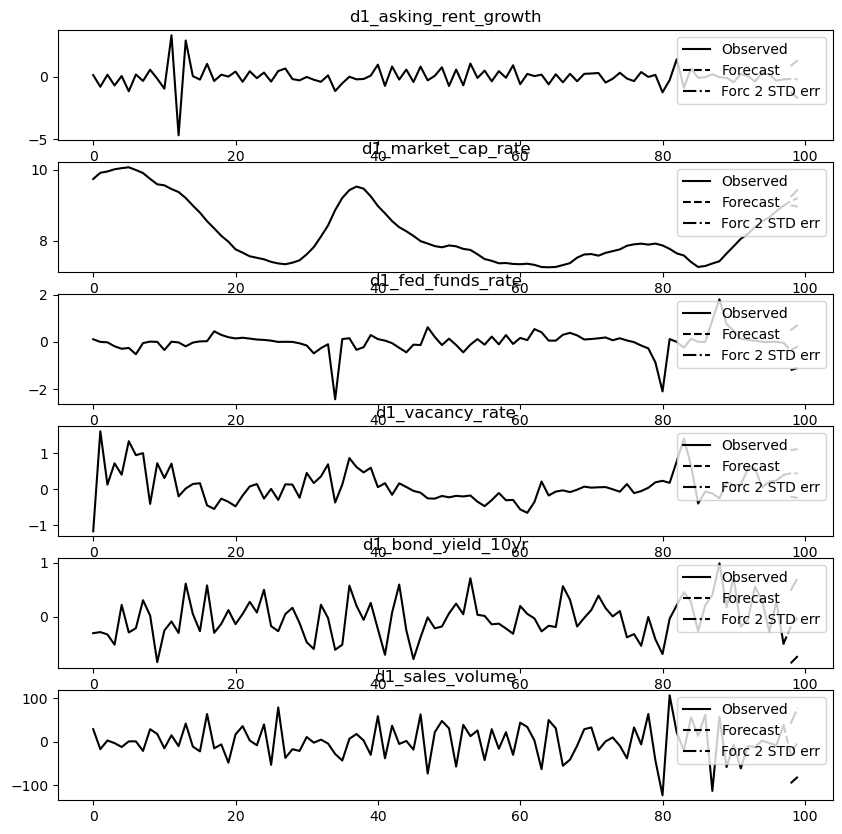

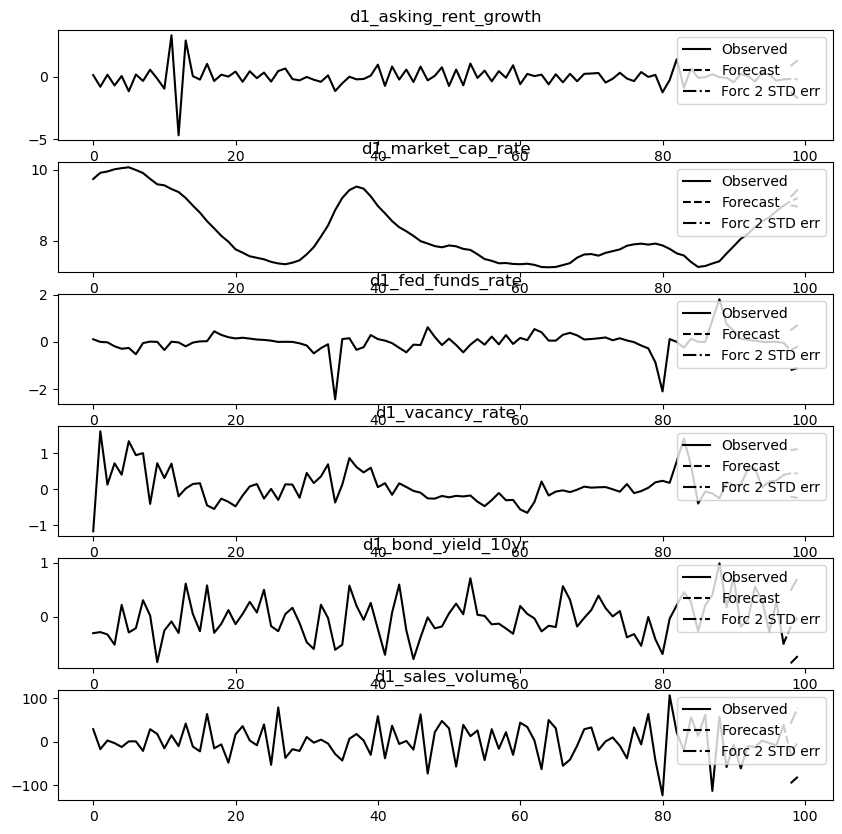

In [173]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson

# -------------------------------------------------
# 0. Variable Selection (ADD THIS SECTION)
# -------------------------------------------------
# List of key variables to include (customize based on domain knowledge)
selected_vars = [
    'market_cap_rate',  # Target variable
    'fed_funds_rate',
    'vacancy_rate',
    'bond_yield_10yr',
    'net_delivered_sf_12_mo',
    'starts_sf_12_mo',
    'under_construction_sf',
    'inventory_sf',
    'asking_rent_growth',
    'total_sales_transactions',
    'sales_volume'

]

# -------------------------------------------------
# 1. Data Preparation
# -------------------------------------------------
# Assuming df has 'period' column and selected variables
#df = df.set_index('period')  # Set time index
original_target = 'asking_rent_growth'

# Filter dataframe to selected variables
df = df[selected_vars]

# -------------------------------------------------
# 2. Automated Preprocessing Pipeline (MODIFIED)
# -------------------------------------------------
def prepare_data(df, target_col, seasonal_period=8, selected_vars=None):
    """End-to-end preprocessing with target preservation"""
    
    # Filter to selected variables if provided
    if selected_vars:
        df = df[selected_vars]
    
    # Keep track of target through transformations
    target_transformations = []
    
    # A. Variance Stabilization
    cv_threshold = 0.5
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    for col in numeric_cols:
        series = df[col].dropna()
        if series.min() > 0:
            cv = series.std()/series.mean()
            if cv > cv_threshold:
                df[f'log_{col}'] = np.log(series)
                if col == target_col:
                    target_transformations.append(f'log_{col}')
            else:
                df[f'orig_{col}'] = series
                if col == target_col:
                    target_transformations.append(f'orig_{col}')
        else:
            df[f'orig_{col}'] = series
            if col == target_col:
                target_transformations.append(f'orig_{col}')
    
    # B. First Differencing
    transformed_cols = [c for c in df.columns if c.startswith(('log_', 'orig_'))]
    
    for col in transformed_cols:
        base_name = col.split('_', 1)[1]
        if adfuller(df[col].dropna())[1] > 0.05:
            df[f'd1_{base_name}'] = df[col].diff().dropna()
            if base_name == target_col:
                target_transformations.append(f'd1_{base_name}')
        else:
            df[f'd1_{base_name}'] = df[col]
    
    # C. Seasonal Differencing
    seasonal_cols = [c for c in df.columns if c.startswith('d1_')]
    
    for col in seasonal_cols:
        try:
            if adfuller(df[col].dropna())[1] > 0.05:
                df[f'sd{seasonal_period}_{col}'] = df[col].diff(seasonal_period).dropna()
        except:
            continue
    
    # D. Final Stationary Selection
    final_cols = []
    for col in df.columns:
        if col.startswith(('sd12_d1_', 'd1_')):
            if adfuller(df[col].dropna())[1] < 0.05:
                final_cols.append(col)
    
    # Ensure target is included
    final_target = target_transformations[-1]
    if final_target not in final_cols:
        final_cols.append(final_target)
    
    return df[final_cols].dropna()

# -------------------------------------------------
# 3. Execute Pipeline (MODIFIED)
# -------------------------------------------------
# Use either selected_vars or default to all variables
stationary_df = prepare_data(df, original_target, selected_vars=selected_vars)

# 4. Granger Causality Filtering
# -------------------------------------------------
def granger_filter(df, target_col, maxlag=2, p_threshold=0.05):
    """Select variables with Granger causal relationship"""
    candidate_vars = [col for col in df.columns if col != target_col]
    significant_vars = []
    
    for var in candidate_vars:
        try:
            test_result = grangercausalitytests(
                df[[target_col, var]], 
                maxlag=maxlag, 
                verbose=False
            )
            p_values = [test_result[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]
            if min(p_values) < p_threshold:
                significant_vars.append(var)
        except:
            continue
    
    return df[[target_col] + significant_vars]

filtered_df = granger_filter(stationary_df, 
                            target_col=stationary_df.filter(like='asking_rent_growth').columns[0])

print(f"Final dataset shape: {filtered_df.shape}")
print(f"Variables: {filtered_df.columns.tolist()}")

# -------------------------------------------------
# 5. VAR Modeling
# -------------------------------------------------
def safe_var_model(df, maxlags=3):
    """VAR modeling with dimension checks"""
    T, k = df.shape
    max_feasible_lags = (T - 1) // (k + 1)  # Conservative estimate
    
    model = VAR(df)
    try:
        lag_results = model.select_order(maxlags=min(maxlags, max_feasible_lags))
        optimal_lag = lag_results.aic
    except:
        optimal_lag = 1
    
    return model.fit(optimal_lag)

var_model = safe_var_model(filtered_df)
print("\nVAR Model Summary:")
print(var_model.summary())

# -------------------------------------------------
# 6. Model Diagnostics
# -------------------------------------------------
print("\nResidual Autocorrelation Test:")
print("Durbin-Watson (want ~2):", durbin_watson(var_model.resid))

# Forecast visualization example
var_model.plot_forecast(steps=2)

In [175]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
#data is time series on monthly basis, let's convert it to quarterly. the time stamp in in the column observation_data and TENEXPCHAREARISPRE is the observation
rrp['observation_date'] = pd.to_datetime(rrp['observation_date'])
rrp.set_index('observation_date', inplace=True)
rrp = rrp.resample('Q').mean()
#change the variable TENEXPCHAREARISPRE to ten_yr_risk_premium
rrp.rename(columns={'TENEXPCHAREARISPRE': 'ten_yr_risk_premium'}, inplace=True)
#each data should start on first of the quarter
rrp.index = rrp.index.to_period('Q').start_time



/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_4668/2505918632.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rrp = rrp.resample('Q').mean()


In [ ]:
inf_e = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/Inflation expectations (1).xlsx')

In [ ]:
#change the column name to period
inf_e.rename(columns={'Model Output Date': 'period'}, inplace=True)

#get data from 2000
inf_e = inf_e[inf_e['period'] >= '2000-01-01']

/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_4668/531473786.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inf_e.rename(columns={'Model Output Date': 'period'}, inplace=True)


In [3]:
cmbs = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/commercial_mortgage.csv')
gdp = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/GDP.csv')

In [6]:
cmbs.head()

,period,ASCMA
0,2000-01-01,1086111
1,2000-04-01,1116557
2,2000-07-01,1138558
3,2000-10-01,1166539
4,2001-01-01,1147919


In [2]:
import pandas as pd

In [19]:
cmbs.head()

,period,oustanding_mortgage,cmbs_to_gdp
0,2000-01-01,1086.111,0.108587
1,2000-04-01,1116.557,0.108957
2,2000-07-01,1138.558,0.110345
3,2000-10-01,1166.539,0.111783
4,2001-01-01,1147.919,0.109636


In [5]:
#change the column name to period

cmbs.rename(columns={'observation_date': 'period'}, inplace=True)
gdp.rename(columns={'observation_date': 'period'}, inplace=True)

In [8]:
cmbs.rename(columns={'ASCMA': 'oustanding_mortgage'}, inplace=True)
gdp.rename(columns={'GDP': 'gdp'}, inplace=True)



In [11]:
#the units in outstanding mortgage is in millions, let's convert it to billions
cmbs['oustanding_mortgage'] = cmbs['oustanding_mortgage'] / 1000

In [13]:
#create a new column in cmbs called cmbs_to_gdp
cmbs['cmbs_to_gdp'] = cmbs['oustanding_mortgage'] / gdp['gdp']


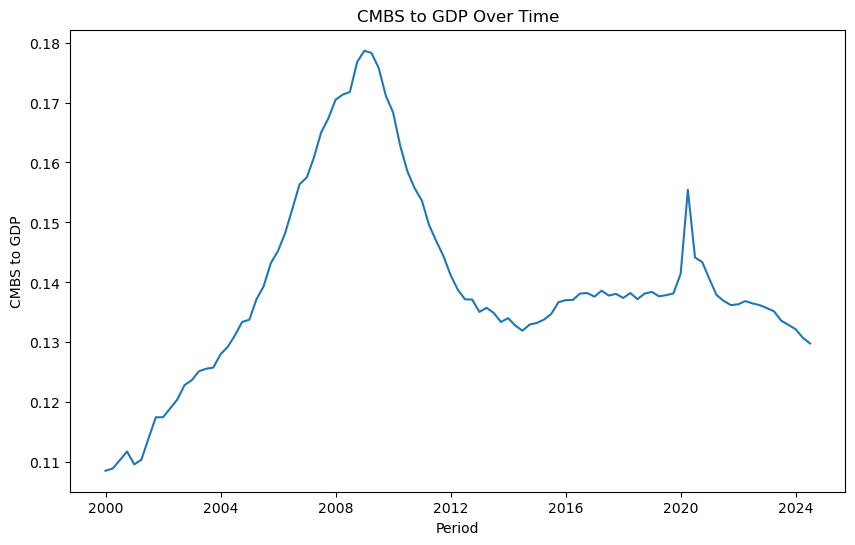

In [21]:
import matplotlib.pyplot as plt
#generate a time plot with period column as x-axis and cmbs_to_gdp as y-axis
plt.figure(figsize=(10, 6))
plt.plot(cmbs['period'], cmbs['cmbs_to_gdp'])
plt.xlabel('Period')
plt.ylabel('CMBS to GDP')
plt.title('CMBS to GDP Over Time')
plt.show()

In [17]:
#change the period column in both dataset to datetime
cmbs['period'] = pd.to_datetime(cmbs['period'])
gdp['period'] = pd.to_datetime(gdp['period'])
